# Étape 5 — Prévision de la demande

**Objectif** : produire une prévision mensuelle (horizon 6 mois) pour les 250 produits, en appliquant à chaque classe le modèle le plus adapté (mémoire §3.6).

**Stratégie d'affectation** :

| Classe / profil | Modèle |
|---|---|
| A non-intermittent | LSTM-like (MLP séquentiel) |
| B | LightGBM (lags + features temporelles + flag obsolescence) |
| C non-intermittent | SARIMA auto_arima (s=12) |
| Intermittent (Z ou ≤30 % de mois actifs) | Croston SBA |
| Obsolète (Étape 4) | Prévision = 0 |
| Cold-start (<6 mois d'historique) | Analogie famille |

**Évaluation** : MAE / RMSE / MAPE sur la fenêtre test (avril-juillet 2025).

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(ROOT))

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='talk')

## 1. Chargement des sorties du pipeline

In [2]:
previsions = pd.read_csv(ROOT/'outputs/tables/previsions_complet.csv', parse_dates=['date'])
metrics = pd.read_csv(ROOT/'outputs/tables/comparaison_modeles.csv')
by_class = pd.read_csv(ROOT/'outputs/tables/forecast_metrics_by_class.csv')
print(f"Prévisions produites : {len(previsions):,}".replace(',', ' '))
print(f"Produits couverts : {previsions['produit_id'].nunique()}")
print(f"Horizon de planification : {previsions['date'].min().date()} → {previsions['date'].max().date()}")

Prévisions produites : 1 500
Produits couverts : 250
Horizon de planification : 2025-08-01 → 2026-01-01


## 2. Répartition des modèles utilisés

In [3]:
previsions[['produit_id','modele_utilise']].drop_duplicates()['modele_utilise'].value_counts()

modele_utilise
sarima         80
obsolete       73
lstm           49
lightgbm       41
croston_sba     7
Name: count, dtype: int64

## 3. Performance par classe ABC × modèle

In [4]:
by_class

,classe_abc,modele,n_produits,mae_moy,rmse_moy,mape_moy
0,A,croston_sba,1,5.937,6.481,75.775
1,A,lstm,49,6.469,7.744,110.560
2,A,obsolete,4,10.812,13.502,100.000
3,B,lightgbm,41,7.597,9.032,78.086
4,B,obsolete,4,25.312,30.429,100.000
5,C,croston_sba,6,4.953,5.810,155.957
6,C,obsolete,4,27.812,31.974,100.000
7,C,sarima,80,9.936,11.811,74.935


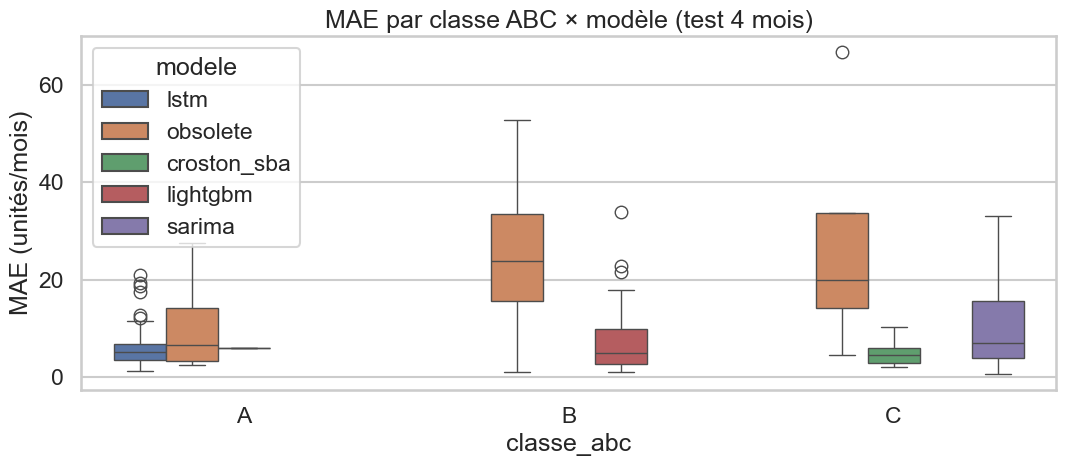

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
sub = metrics.dropna(subset=['mae'])
sns.boxplot(data=sub, x='classe_abc', y='mae', hue='modele', order=['A','B','C'], ax=ax)
ax.set_title('MAE par classe ABC × modèle (test 4 mois)'); ax.set_ylabel('MAE (unités/mois)')
plt.tight_layout(); plt.show()

## 4. Importance des features LightGBM

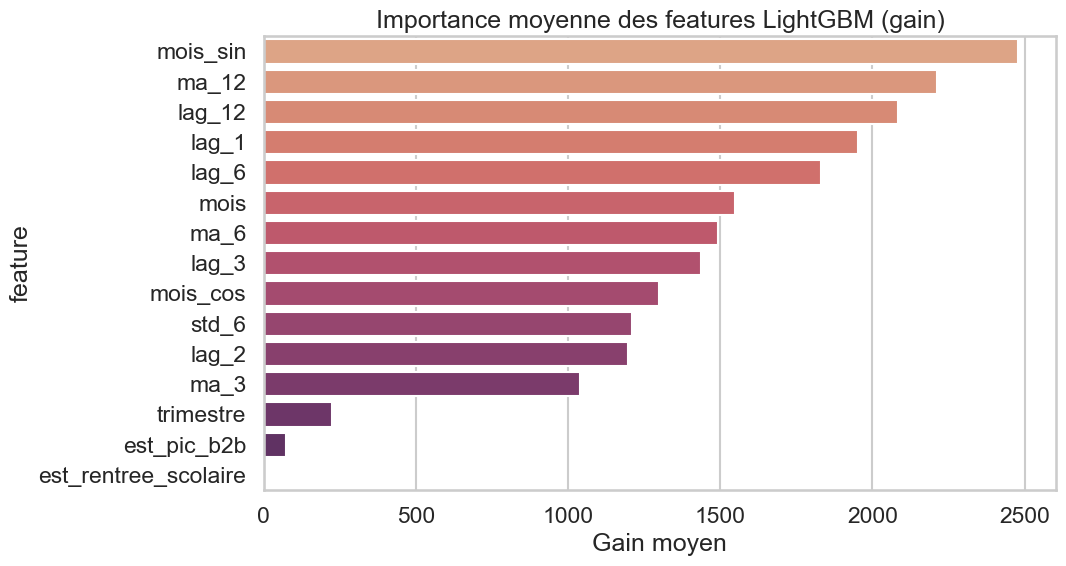

In [6]:
fi = pd.read_csv(ROOT/'outputs/tables/lgbm_feature_importance.csv')
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=fi, x='importance_moy', y='feature', hue='feature', palette='flare', ax=ax, legend=False)
ax.set_title('Importance moyenne des features LightGBM (gain)')
ax.set_xlabel('Gain moyen')
plt.tight_layout(); plt.show()

## 5. Aperçu des prévisions (10 premières lignes)

In [7]:
previsions.head(10)

,produit_id,date,prevision,modele_utilise,intervalle_confiance_bas,intervalle_confiance_haut
0,P0023,2025-08-01,18.906219,lstm,16.070286,21.742151
1,P0023,2025-09-01,14.189375,lstm,12.060969,16.317781
2,P0023,2025-10-01,21.340793,lstm,18.139674,24.541912
3,P0023,2025-11-01,9.245698,lstm,7.858843,10.632553
4,P0023,2025-12-01,22.890638,lstm,19.457042,26.324234
5,P0023,2026-01-01,11.063306,lstm,9.403810,12.722801
6,P0024,2025-08-01,8.497841,lstm,7.223165,9.772518
7,P0024,2025-09-01,2.669107,lstm,2.268741,3.069474
8,P0024,2025-10-01,13.467297,lstm,11.447203,15.487392
9,P0024,2025-11-01,31.690915,lstm,26.937278,36.444553


## 6. Conclusion

Le pipeline de prévision tourne en ~1-2 min sur poste standard.
- Chaque produit reçoit le modèle adapté à sa classe et son profil de demande.
- Les produits obsolètes (Étape 4) ne reçoivent aucune prévision (0).
- L'intervalle de confiance simple (±15-20 %) sera affiné par les écarts résiduels de l'évaluation test pour le tableau de bord.

Les sorties (`previsions_complet.csv`) alimentent directement l'**Étape 6 — Optimisation linéaire des commandes**.